<a href="https://colab.research.google.com/github/monroeu/MG628/blob/main/MG628_Week5_Descriptive_Analytics_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MG628 Week 5 — Descriptive Analytics and Statistics
**Instructor / student lab** · Canonical sales and healthcare records; six explicitly synthetic distribution series.

**Workflow:** Explain → Excel → Python → Managerial action. This notebook runs in Jupyter with the three CSV files alongside it, or in Google Colab after uploading them.

## 1 · Imports and reproducible data loading
In Colab, upload `sales_week5.csv`, `healthcare_week5.csv`, and `synthetic_distributions.csv` when prompted. Never use sensitive student data in a public notebook.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =====================================================
# MG628 WEEK 5 - LOAD EXISTING DATASETS
# =====================================================

# These filenames match the files in your Colab sidebar.
sales_file = Path("/content/sales_week5.csv")
health_file = Path("/content/healthcare_week5.csv")
distributions_file = Path("/content/synthetic_distributions.csv")

# Verify that all required files exist
for file in [sales_file, health_file, distributions_file]:
    if not file.exists():
        raise FileNotFoundError(
            f"Missing file: {file.name}. "
            "Check the Files panel in Google Colab."
        )

# Read the three CSV datasets
sales = pd.read_csv(sales_file)
health = pd.read_csv(health_file)
distributions = pd.read_csv(distributions_file)

# =====================================================
# VERIFY DATA LOADING
# =====================================================

print("MG628 WEEK 5 - DATA LOADING SUCCESSFUL")
print("=" * 50)

print(f"Sales records: {len(sales)}")
print(f"Healthcare records: {len(health)}")
print(f"Distribution records: {len(distributions)}")

# Check expected numbers of records
assert len(sales) == 200, "Sales dataset should have 200 records."
assert len(health) == 50, "Healthcare dataset should have 50 records."
assert len(distributions) == 400, "Distribution dataset should have 400 records."

# Verify required sales columns
required_sales_columns = {
    "Date", "Product", "Region", "Salesperson",
    "Units Sold", "Unit Price", "Total Revenue"
}

missing_columns = required_sales_columns - set(sales.columns)

if missing_columns:
    raise ValueError(
        f"Missing sales columns: {sorted(missing_columns)}"
    )

print("\nAll validation checks passed!")

# Preview each dataset
print("\nSALES DATASET")
display(sales.head())

print("\nHEALTHCARE DATASET")
display(health.head())

print("\nSYNTHETIC DISTRIBUTIONS")
display(distributions.head())


MG628 WEEK 5 - DATA LOADING SUCCESSFUL
Sales records: 200
Healthcare records: 50
Distribution records: 400

All validation checks passed!

SALES DATASET


,Date,Product,Region,Salesperson,Units Sold,Unit Price,Total Revenue
0,3/4/2023,Smartphone,North,Diana,43,449.96,19348.28
1,2/2/2023,Keyboard,East,Diana,19,750.65,14262.35
2,1/26/2024,Laptop,West,Charlie,14,1214.30,17000.20
3,4/20/2023,Tablet,South,Alice,18,572.33,10301.94
4,8/7/2023,Keyboard,North,Diana,48,65.47,3142.56



HEALTHCARE DATASET


,Department,Facility,Physician_ID,Patient_Admissions,Average_Cost_per_Patient,Total_Billing
0,Oncology,Downtown Campus,DR-008,12,2314.68,27776.16
1,Orthopedics,North Clinic,DR-004,18,1492.53,26865.54
2,Pediatrics,North Clinic,DR-003,25,2382.80,59570.00
3,Orthopedics,Downtown Campus,DR-003,8,1416.10,11328.80
4,Orthopedics,West Medical Center,DR-018,15,4282.04,64230.60



SYNTHETIC DISTRIBUTIONS


,Normal,Right_Skew,Left_Skew,Mesokurtic,Leptokurtic,Platykurtic
0,84.119285,95.735644,109.689884,0.743155,1.181587,0.875598
1,88.760795,83.050175,103.546060,-0.226385,0.346332,-0.460117
2,124.770927,135.747014,91.473266,0.064348,-0.265151,-1.385886
3,100.191486,139.867379,88.510401,0.033467,0.397424,0.625458
4,71.289790,83.240027,103.340813,0.760116,-0.152839,-0.579257


## 2 · Data-quality gate
Data integrity comes before statistical interpretation. Compare reported revenue with quantity × unit price; decide whether discrepancies are rounding, business rules, or errors before changing data.

In [13]:
print(sales.isna().sum().to_string())
print('Duplicates:',sales.duplicated().sum())
print('Healthcare missing values:',int(health.isna().sum().sum()))
print('Revenue sample:', sales[["Product","Units Sold","Unit Price","Total Revenue"]].head().to_string(index=False))

Date             0
Product          0
Region           0
Salesperson      0
Units Sold       0
Unit Price       0
Total Revenue    0
Duplicates: 0
Healthcare missing values: 0
Revenue sample:    Product  Units Sold  Unit Price  Total Revenue
Smartphone          43      449.96       19348.28
  Keyboard          19      750.65       14262.35
    Laptop          14     1214.30       17000.20
    Tablet          18      572.33       10301.94
  Keyboard          48       65.47        3142.56


## 3 · Center: mean, median and mode
The mean uses all observations; the median resists single extreme values; the mode identifies the most frequent value or category. Worked service-time illustration: [45,48,50,52,205], mean 80 and median 50.

In [5]:
revenue=sales["Total Revenue"]
print('Mean',revenue.mean(),'Median',revenue.median(),'Mode units',sales['Units Sold'].mode().tolist())
print('Illustration:',np.mean([45,48,50,52,205]),np.median([45,48,50,52,205]))

Mean 21472.177249999997 Median 17638.58 Mode units [35]
Illustration: 80.0 50.0


## 4 · Category frequency versus numerical histogram
Frequency table counts products. Histogram bins numerical revenue amounts. They answer different questions.

,Count
Product,
Monitor,51
Tablet,41
Keyboard,38
Smartphone,37
Laptop,33


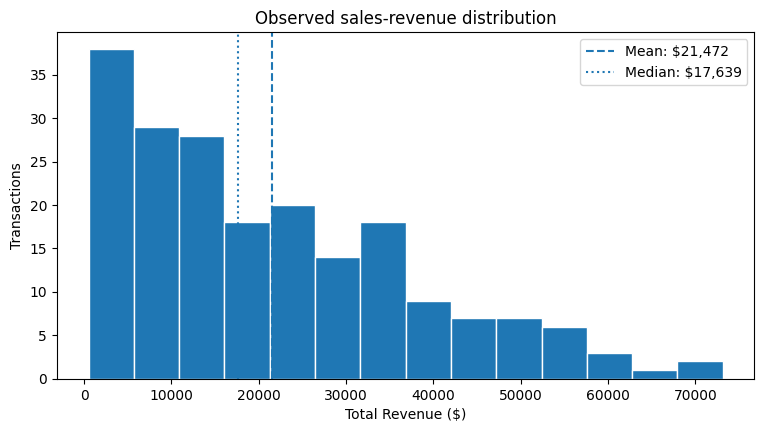

In [6]:
display(sales['Product'].value_counts().rename_axis('Product').to_frame('Count'))
fig,ax=plt.subplots(figsize=(9,4.5));ax.hist(revenue,bins=14,edgecolor='white');ax.axvline(revenue.mean(),label=f'Mean: ${revenue.mean():,.0f}',linestyle='--');ax.axvline(revenue.median(),label=f'Median: ${revenue.median():,.0f}',linestyle=':');ax.set(title='Observed sales-revenue distribution',xlabel='Total Revenue ($)',ylabel='Transactions');ax.legend();plt.show()

## 5 · Spread and quartiles
Population SD uses N; sample SD uses N−1. The course uses sample SD (Excel `STDEV.S`; pandas `std(ddof=1)`). Outlier fences identify records for review—not deletion.

In [7]:
q1,q3=revenue.quantile([.25,.75]); iqr=q3-q1;low=q1-1.5*iqr;high=q3+1.5*iqr
summary=pd.Series({'n':revenue.count(),'mean':revenue.mean(),'median':revenue.median(),'min':revenue.min(),'max':revenue.max(),'range':revenue.max()-revenue.min(),'sample variance':revenue.var(ddof=1),'sample SD':revenue.std(ddof=1),'Q1':q1,'Q3':q3,'IQR':iqr,'lower fence':low,'upper fence':high,'skew':revenue.skew(),'excess kurtosis':revenue.kurt()});display(summary.round(3));print('Upper outliers:',sum(revenue>high))

,0
n,2.000000e+02
mean,2.147218e+04
median,1.763858e+04
min,5.105700e+02
max,7.313691e+04
range,7.262634e+04
sample variance,2.690129e+08
sample SD,1.640161e+04
Q1,8.712458e+03
Q3,3.191617e+04


Upper outliers: 2


In [ ]:
fig,ax=plt.subplots(figsize=(9,2.7));ax.boxplot(revenue,vert=False);ax.set(xlabel='Revenue ($)',title='Sales revenue: box plot (1.5 × IQR fences)');plt.show()

## 6 · Healthcare transfer
Compare admissions and billing. Large SD indicates variation, not automatically inadequate performance. Do not infer causal explanations from descriptive statistics.

,n,mean_admissions,sd_admissions,total_billing
Department,,,,
Cardiology,10,16.50,3.03,820490.10
Emergency,10,32.80,7.33,977719.25
Oncology,9,10.67,2.35,296555.51
Orthopedics,11,13.55,3.78,346548.24
Pediatrics,10,26.50,3.03,564562.02


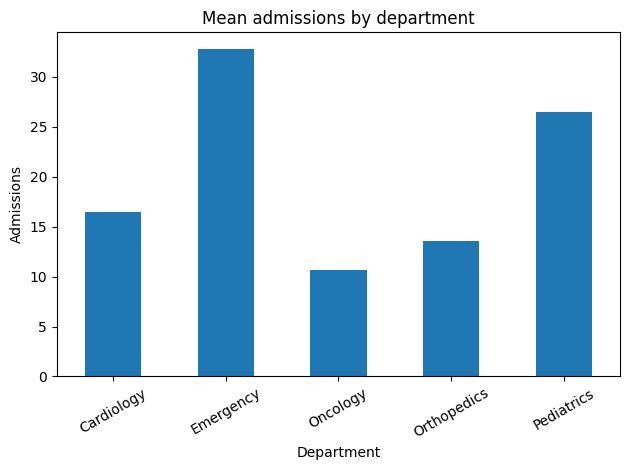

In [8]:
dept=health.groupby('Department').agg(n=('Patient_Admissions','size'),mean_admissions=('Patient_Admissions','mean'),sd_admissions=('Patient_Admissions','std'),total_billing=('Total_Billing','sum'));display(dept.round(2));dept['mean_admissions'].plot(kind='bar',title='Mean admissions by department',ylabel='Admissions',rot=30);plt.tight_layout();plt.show()

## 7 · Normal distribution and empirical rule
When the normal model is suitable, roughly 68%, 95%, and 99.7% lie within 1, 2, and 3 standard deviations. For μ=100 and σ=15 the 95% interval is 70–130.

In [9]:
mu,sd=100,15
for k,p in [(1,'68%'),(2,'95%'),(3,'99.7%')]:print(p,mu-k*sd,mu+k*sd)

68% 85 115
95% 70 130
99.7% 55 145


## 8 · Skewness and kurtosis: SYNTHETIC demonstrations
Positive skew = longer right tail; negative = longer left tail. Excess kurtosis focuses on propensity for extremes; normal benchmark is zero.

,Normal,Right_Skew,Left_Skew,Mesokurtic,Leptokurtic,Platykurtic
mean,99.878,100.000,100.000,0.000,0.000,0.000
median,100.036,96.552,103.566,-0.015,-0.052,-0.068
std,14.824,15.000,15.000,1.000,1.000,1.000
skew,-0.039,0.952,-0.999,0.000,-0.165,0.048
kurt,0.353,0.799,0.727,-0.192,2.756,-1.169


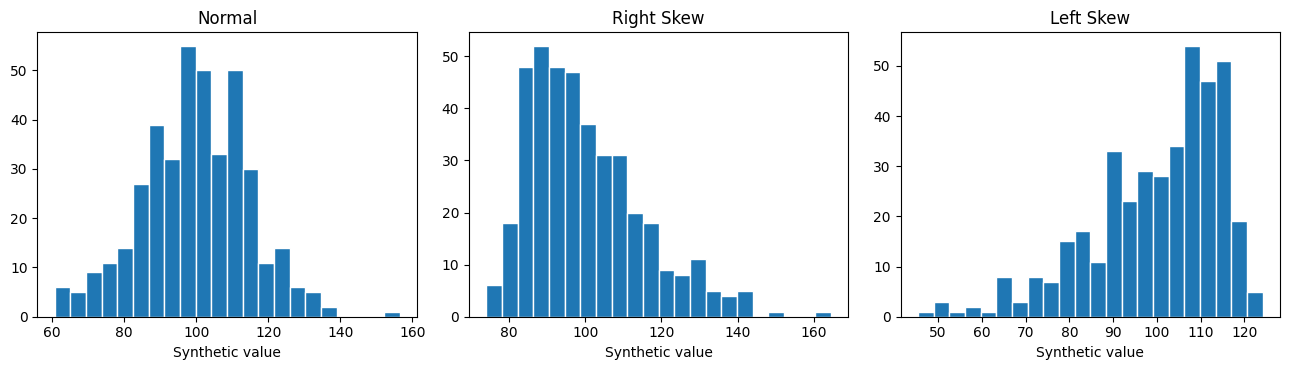

In [10]:
display(distributions.agg(['mean','median','std','skew','kurt']).round(3))
fig,axs=plt.subplots(1,3,figsize=(13,3.8));
for ax,col in zip(axs,['Normal','Right_Skew','Left_Skew']):ax.hist(distributions[col],bins=22,edgecolor='white');ax.set_title(col.replace('_',' '));ax.set_xlabel('Synthetic value')
plt.tight_layout();plt.show()

In [ ]:
fig,axs=plt.subplots(1,3,figsize=(13,3.8));
for ax,col in zip(axs,['Mesokurtic','Leptokurtic','Platykurtic']):ax.hist(distributions[col],bins=24,edgecolor='white');ax.set_title(f'{col}: kurt={distributions[col].kurt():.2f}');ax.set_xlabel('Standardized synthetic value')
plt.tight_layout();plt.show()

## 9 · Excel ↔ Python QA
These checks use canonical values calculated independently from the original CSV; the Excel workbook uses identical samples and statistical conventions.

In [11]:
expected={'mean':21472.18,'median':17638.58,'sample_sd':16401.61}
actual={'mean':revenue.mean(),'median':revenue.median(),'sample_sd':revenue.std(ddof=1)}
for k in expected:print(k,round(actual[k],2),'PASS' if abs(round(actual[k],2)-expected[k])<.011 else 'VERIFY SOURCE')
assert all(abs(round(actual[k],2)-expected[k])<.011 for k in expected)

mean 21472.18 PASS
median 17638.58 PASS
sample_sd 16401.61 PASS


## 10 · Student challenge
1. Which statistic better describes a typical transaction if high-value sales pull the mean upward? Explain.
2. Compute group SD for two healthcare departments and propose a staffing investigation.
3. Explain why a synthetic normal model is not automatically appropriate for billing data.
4. If Excel and Python disagree, inspect rows, filters, missing data, quartile convention, and sample/population choices.